In [19]:
from pathlib import Path
import os

ROOT = Path("/Users/prathiksharamesh/single-cell-lung-atlas-covid19")

print(ROOT) 

/Users/prathiksharamesh/single-cell-lung-atlas-covid19


In [20]:
import scanpy as sc 
adata = sc.read_h5ad( 
    ROOT / "data" / "processed" / "GSM5226574_C51ctr_normalized.h5ad"
)

In [21]:
adata.raw = adata  

In [22]:
sc.pp.highly_variable_genes(adata, n_top_genes = 2000)

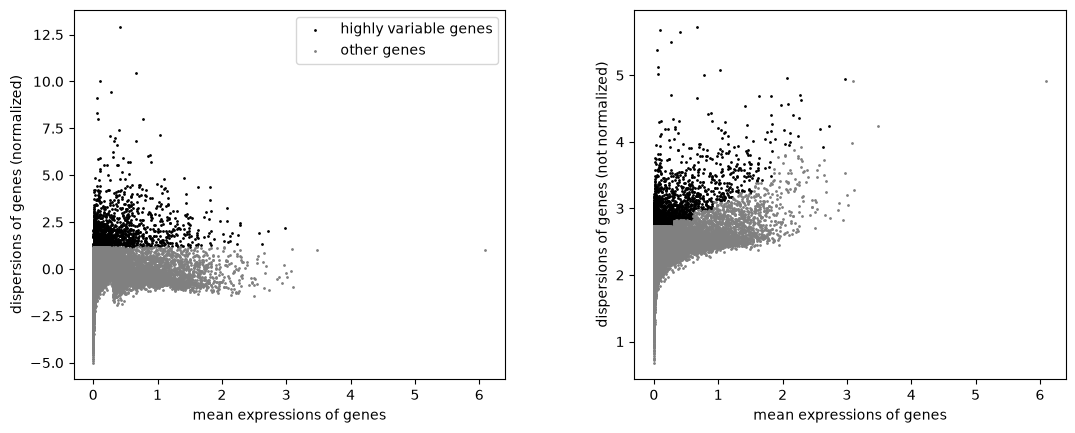

In [23]:
sc.pl.highly_variable_genes(adata)

In [24]:
adata = adata[:, adata.var.highly_variable]

In [25]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt', 'pct_counts_ribo'])

/opt/miniconda3/envs/lungatlas/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [26]:
sc.pp.scale(adata, max_value=10)

In [27]:
sc.tl.pca(adata, svd_solver='arpack')

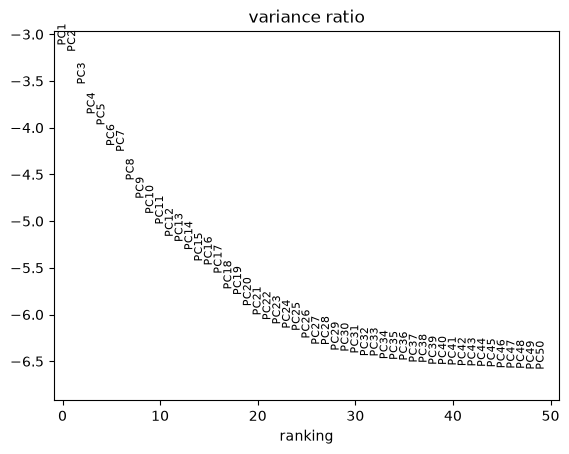

In [28]:
sc.pl.pca_variance_ratio(adata, log=True, n_pcs = 50)

In [29]:
sc.pp.neighbors(adata, n_pcs = 30)

In [30]:
sc.tl.umap(adata)

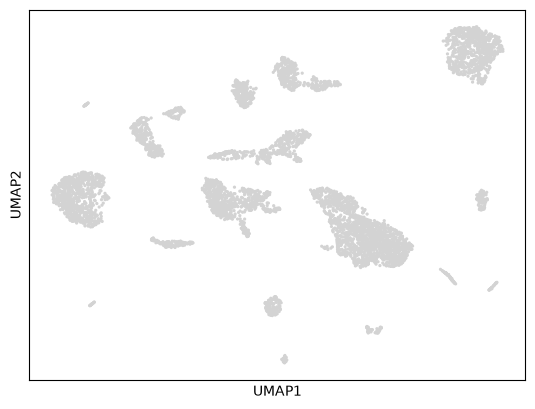

In [31]:
sc.pl.umap(adata)

In [32]:
sc.tl.leiden(adata, resolution = 0.5)

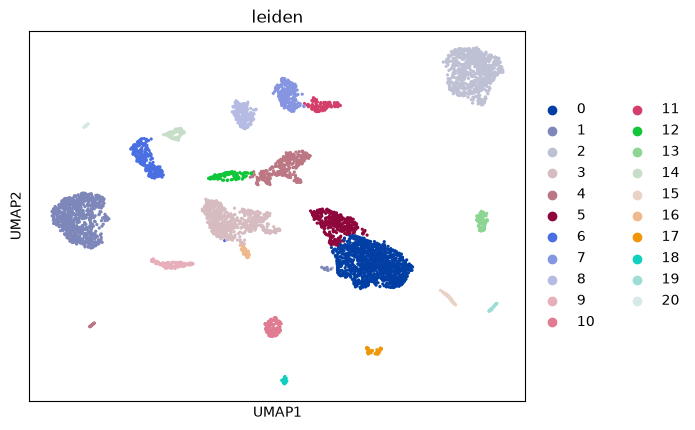

In [33]:
sc.pl.umap(adata, color = ['leiden'])